# 5: SVMs and Perceptrons

In [6]:
# Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns; sns.set()

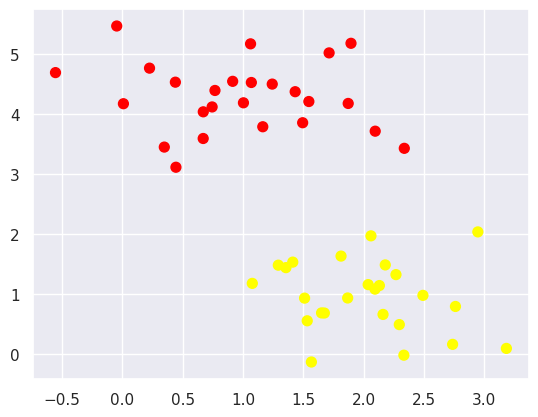

In [7]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=50,
    centers=2,
    random_state=0,
    cluster_std=0.60
)

y = 2 * y - 1

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.show()

## Implement Perceptron Loss

In [8]:
def perceptron_loss(y_true, scores):
    return np.mean(np.maximum(0, -y_true * scores))

In [9]:
def perceptron_subgradient(X, y_true, scores):
    margin = y_true * scores
    misclassified = margin <= 0

    if not np.any(misclassified):
        return np.zeros(X.shape[1]), 0.0

    grad_w = -np.mean(
        y_true[misclassified, None] * X[misclassified],
        axis=0
    )
    grad_b = -np.mean(y_true[misclassified])

    return grad_w, grad_b

In [10]:
def train_perceptron(X, y, learning_rate=0.01, n_iters=1000):
    w = np.zeros(X.shape[1])
    b = 0.0
    loss_history = []

    for i in range(n_iters):
        scores = X @ w + b

        loss = perceptron_loss(y, scores)
        loss_history.append(loss)

        grad_w, grad_b = perceptron_subgradient(X, y, scores)

        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

    return w, b, loss_history

In [11]:
# Run training loop

w_perceptron, b_perceptron, perceptron_history = train_perceptron(
    X,
    y,
    learning_rate=0.01,
    n_iters=1000
)

print("Final Perceptron Loss:", perceptron_history[-1])

perceptron_scores = X @ w_perceptron + b_perceptron
perceptron_predictions = np.where(perceptron_scores >= 0, 1, -1)

perceptron_accuracy = np.mean(perceptron_predictions == y)

print("Perceptron Accuracy:", perceptron_accuracy)

Final Perceptron Loss: 0.0
Perceptron Accuracy: 1.0


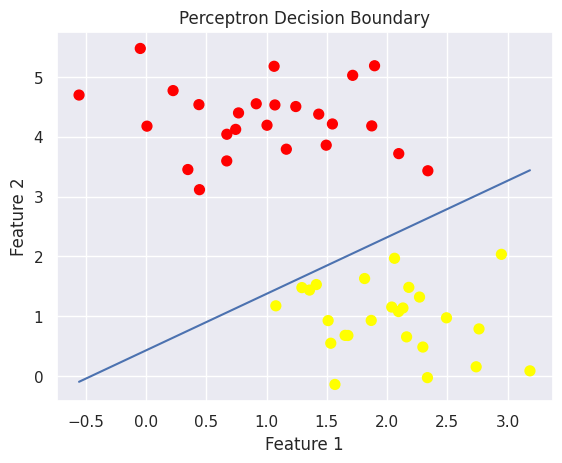

In [ ]:
# Plot Decision Boundary

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

x_boundary = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_boundary = -(w_perceptron[0] * x_boundary + b_perceptron) / w_perceptron[1]

plt.plot(x_boundary, y_boundary)
plt.title("Perceptron Decision Boundary")
plt.show()

## Implement Hinge Loss

In [14]:
def hinge_loss(y_true, scores):
    return np.mean(np.maximum(0, 1 - y_true * scores))

In [15]:
def hinge_subgradient(X, y_true, scores):
    margin = y_true * scores
    inside_margin = margin < 1

    if not np.any(inside_margin):
        return np.zeros(X.shape[1]), 0.0

    grad_w = -np.mean(
        y_true[inside_margin, None] * X[inside_margin],
        axis=0
    )
    grad_b = -np.mean(y_true[inside_margin])

    return grad_w, grad_b

In [16]:
def train_hinge(X, y, learning_rate=0.01, n_iters=1000):
    w = np.zeros(X.shape[1])
    b = 0.0
    loss_history = []

    for i in range(n_iters):
        scores = X @ w + b

        loss = hinge_loss(y, scores)
        loss_history.append(loss)

        grad_w, grad_b = hinge_subgradient(X, y, scores)

        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

    return w, b, loss_history

In [17]:
# Run training loop

w_hinge, b_hinge, hinge_history = train_hinge(
    X,
    y,
    learning_rate=0.01,
    n_iters=1000
)

hinge_scores = X @ w_hinge + b_hinge
hinge_predictions = np.where(hinge_scores >= 0, 1, -1)

hinge_accuracy = np.mean(hinge_predictions == y)

print("Final Hinge Loss:", hinge_history[-1])
print("Hinge Accuracy:", hinge_accuracy)

Final Hinge Loss: 0.0
Hinge Accuracy: 1.0


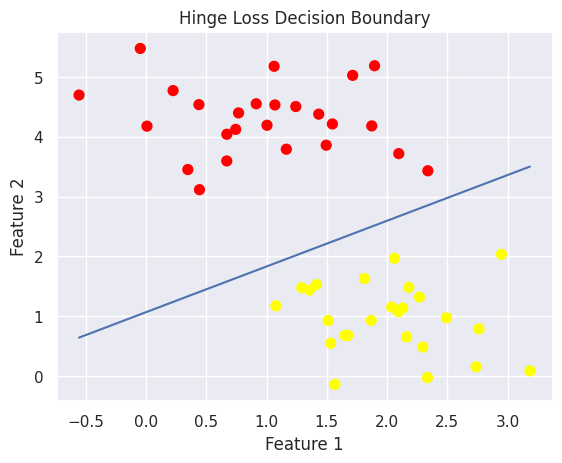

In [ ]:
# Visualize decision boundary

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

x_boundary = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_boundary = -(w_hinge[0] * x_boundary + b_hinge) / w_hinge[1]

plt.plot(x_boundary, y_boundary)
plt.title("Hinge Loss Decision Boundary")
plt.show()